In [1]:
import sys, platform, hashlib, datetime, zoneinfo
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ===== SEL IDENTITAS - JANGAN DIHAPUS =====
NAMA = "Radit Firansah"
NIM = "244107020196"
N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
print('Parameter :', PARAM)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Radit Firansah
NIM : 244107020196 | N = 196
Parameter : {'bins': 8, 'clip': 1.5, 'tile': 2, 'L': 4}
WAKTU : 2026-09-27 18:44:25 WIB
SISTEM : 3.12.14 Linux-7.2.6-1-cachyos-x86_64-with-glibc2.44
TOKEN : 5b501af682513822


In [ ]:
# ===== AKSES DATASET DARI GOOGLE DRIVE =====
# Colab : tambahkan folder Drive yang dibagikan ke "My Drive"
#         (klik kanan folder > Add shortcut to Drive), lalu jalankan sel ini.
# Lokal : taruh folder dataset di ./PCVK (opsional).
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    _MYDRIVE = Path('/content/drive/MyDrive')
except Exception:
    _MYDRIVE = Path('.')


def _cari_dataset():
    kandidat = [_MYDRIVE / 'PCVK' / 'Images', _MYDRIVE / 'PCVK']
    for p in kandidat:
        if (p / 'lena.jpg').exists():
            return p
    try:
        for p in _MYDRIVE.rglob('lena.jpg'):
            return p.parent
    except Exception:
        pass
    return kandidat[0]


CONTOH = _cari_dataset()   # citra contoh bersama (lena.jpg, galaxy.jpg, noises/, ...)
BASE = CONTOH / NIM        # citra pribadi (KTM1a-d.jpg, OBJ1.jpg, NIGHT1.jpg)
if not (BASE / 'KTM1a.jpg').exists():
    BASE = CONTOH          # fallback ke citra contoh bila folder NIM belum ada

print('CONTOH :', CONTOH)
print('BASE   :', BASE)
print('Isi CONTOH:', sorted(p.name for p in CONTOH.iterdir())[:15])

In [ ]:
from pathlib import Path

DIR = CONTOH
print('Isi folder contoh:', [file.name for file in DIR.iterdir()])

## E-1 Percobaan Histogram

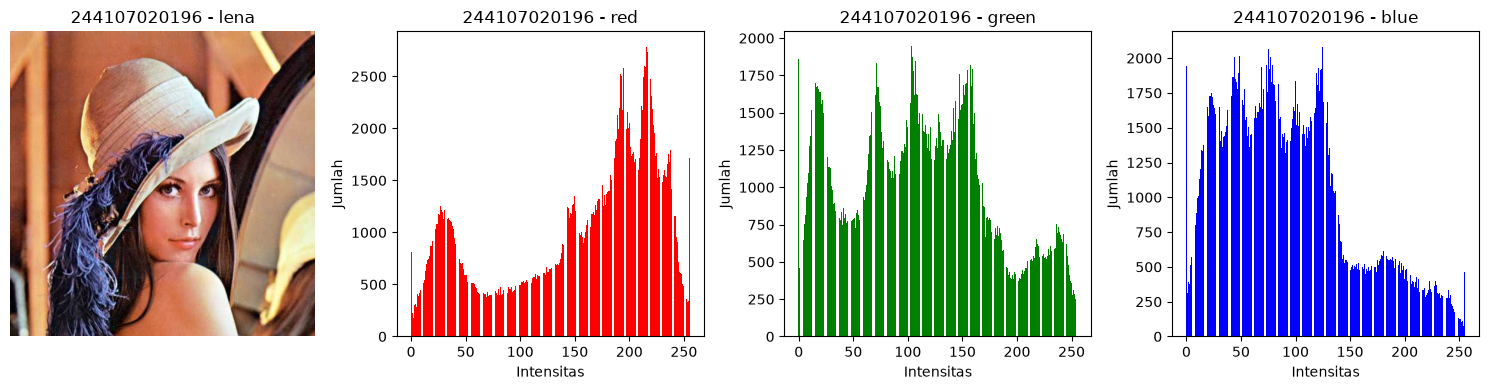

In [3]:
# Membaca lena.jpg
lena = cv.imread(str(DIR / 'lena.jpg'))
lena_rgb = cv.cvtColor(lena, cv.COLOR_BGR2RGB)

# Histogram manual kanal merah, hijau, dan biru
merah = np.zeros(256, dtype=int)
hijau = np.zeros(256, dtype=int)
biru = np.zeros(256, dtype=int)

for baris in lena_rgb:
    for piksel in baris:
        merah[piksel[0]] += 1
        hijau[piksel[1]] += 1
        biru[piksel[2]] += 1

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(lena_rgb)
plt.title(NIM + ' - lena')
plt.axis('off')
for nomor, data, warna in [(2, merah, 'red'), (3, hijau, 'green'), (4, biru, 'blue')]:
    plt.subplot(1, 4, nomor)
    plt.bar(range(256), data, color=warna)
    plt.title(NIM + ' - ' + warna)
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

In [4]:
# Membandingkan histogram manual, NumPy, dan OpenCV
abu = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)
manual = np.zeros(256, dtype=int)
for baris in abu:
    for piksel in baris:
        manual[piksel] += 1

hist_numpy, batas = np.histogram(abu, bins=256, range=(0, 256))
hist_cv = cv.calcHist([abu], [0], None, [256], [0, 256]).ravel().astype(int)
print('Selisih lena manual - NumPy :', np.max(abs(manual - hist_numpy)))
print('Selisih lena manual - OpenCV:', np.max(abs(manual - hist_cv)))

lena_lc = cv.imread(str(DIR / 'lena_lc.jpg'), cv.IMREAD_GRAYSCALE)
manual_lc = np.zeros(256, dtype=int)
for baris in lena_lc:
    for piksel in baris:
        manual_lc[piksel] += 1
hist_numpy_lc, batas = np.histogram(lena_lc, bins=256, range=(0, 256))
hist_cv_lc = cv.calcHist([lena_lc], [0], None, [256], [0, 256]).ravel().astype(int)
print('Selisih lena_lc manual - NumPy :', np.max(abs(manual_lc - hist_numpy_lc)))
print('Selisih lena_lc manual - OpenCV:', np.max(abs(manual_lc - hist_cv_lc)))

Selisih lena manual - NumPy : 0
Selisih lena manual - OpenCV: 0
Selisih lena_lc manual - NumPy : 0
Selisih lena_lc manual - OpenCV: 0


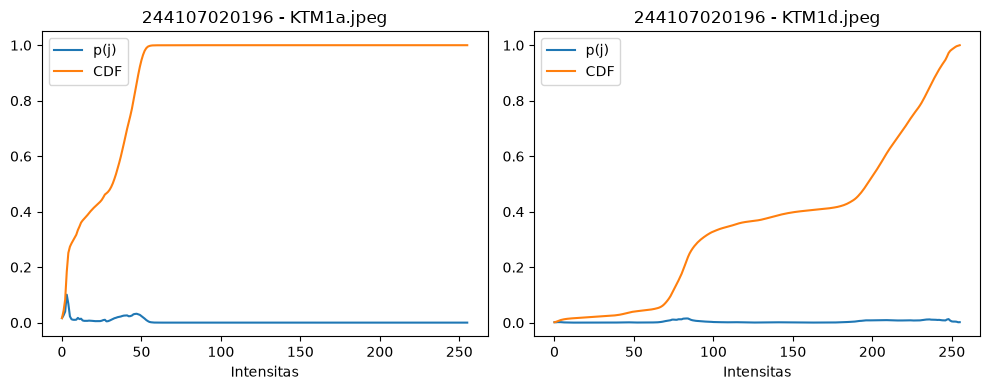

In [5]:
# Histogram ternormalisasi dan CDF citra KTM yang tersedia
nama_file = ['KTM1a.jpg', 'KTM1d.jpg']
plt.figure(figsize=(10, 4))
for nomor, nama in enumerate(nama_file, 1):
    gambar = cv.imread(str(BASE / nama), cv.IMREAD_GRAYSCALE)
    histogram = np.zeros(256, dtype=int)
    for baris in gambar:
        for piksel in baris:
            histogram[piksel] += 1
    probabilitas = histogram / gambar.size
    cdf = np.cumsum(probabilitas)
    plt.subplot(1, 2, nomor)
    plt.plot(probabilitas, label='p(j)')
    plt.plot(cdf, label='CDF')
    plt.title(NIM + ' - ' + nama)
    plt.xlabel('Intensitas')
    plt.legend()
plt.tight_layout()
plt.show()

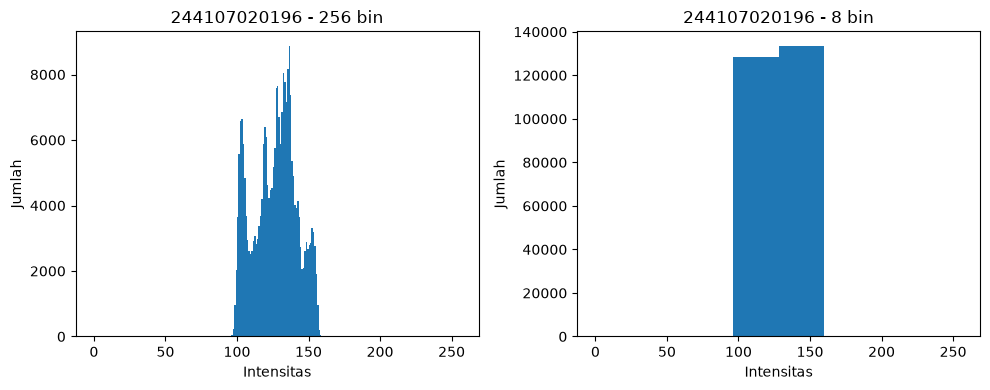

In [6]:
# Perbandingan 256 bin dan jumlah bin dari parameter NIM
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(lena_lc.ravel(), bins=256, range=(0, 256))
plt.title(NIM + ' - 256 bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.subplot(1, 2, 2)
plt.hist(lena_lc.ravel(), bins=PARAM['bins'], range=(0, 256))
plt.title(NIM + ' - ' + str(PARAM['bins']) + ' bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

**Jawaban E-1:** Histogram manual, NumPy, dan OpenCV menghasilkan selisih maksimum 0 pada citra contoh. Jumlah bin yang lebih sedikit menggabungkan beberapa rentang intensitas, sehingga detail distribusi piksel berkurang.

## E-2 Percobaan Histogram Equalization

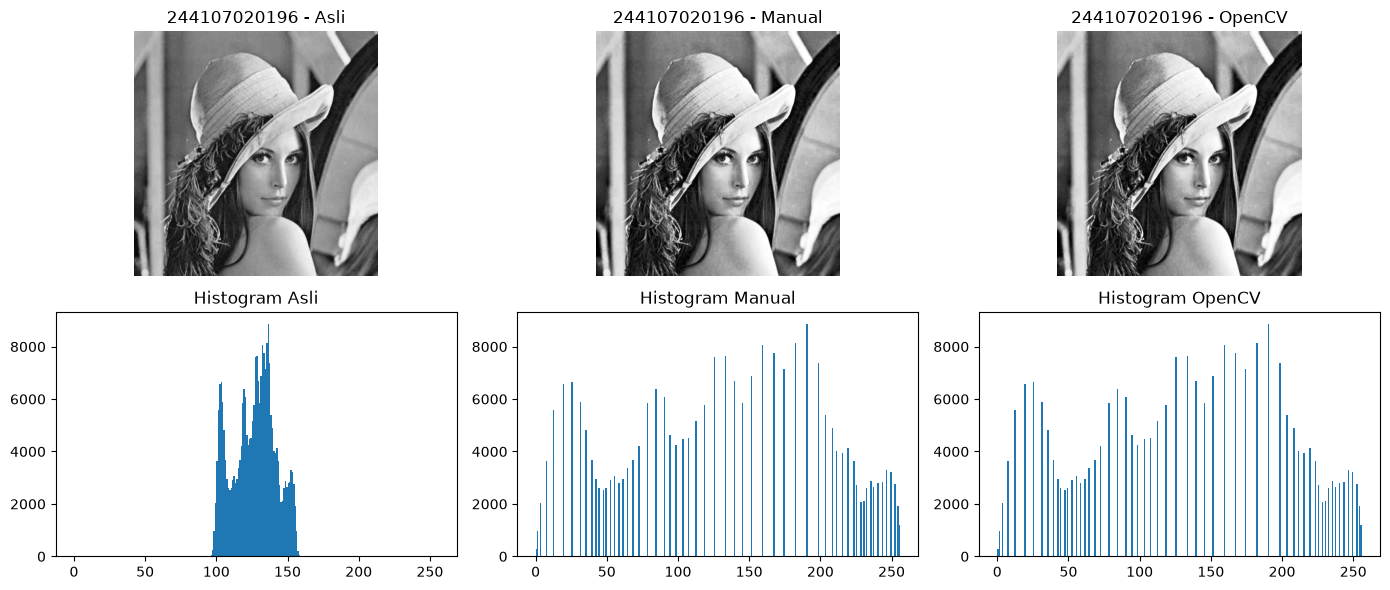

Selisih maksimum manual dan OpenCV: 0


In [7]:
# Equalization manual pada lena_lc.jpg
histogram = np.zeros(256, dtype=int)
for baris in lena_lc:
    for piksel in baris:
        histogram[piksel] += 1
cdf = np.cumsum(histogram) / lena_lc.size
pemetaan = np.round(255 * cdf).astype(np.uint8)
lena_lc_manual = pemetaan[lena_lc]
lena_lc_cv = cv.equalizeHist(lena_lc)

plt.figure(figsize=(14, 6))
for nomor, gambar, judul in [(1, lena_lc, 'Asli'), (2, lena_lc_manual, 'Manual'), (3, lena_lc_cv, 'OpenCV')]:
    plt.subplot(2, 3, nomor)
    plt.imshow(gambar, cmap='gray')
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')
for nomor, gambar, judul in [(4, lena_lc, 'Asli'), (5, lena_lc_manual, 'Manual'), (6, lena_lc_cv, 'OpenCV')]:
    plt.subplot(2, 3, nomor)
    plt.hist(gambar.ravel(), bins=256, range=(0, 256))
    plt.title('Histogram ' + judul)
plt.tight_layout()
plt.show()
print('Selisih maksimum manual dan OpenCV:', np.max(abs(lena_lc_manual.astype(int) - lena_lc_cv.astype(int))))

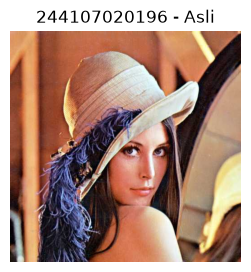

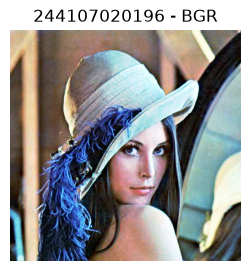

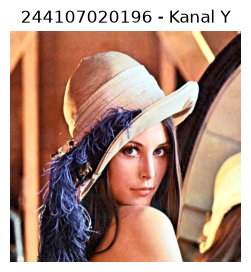

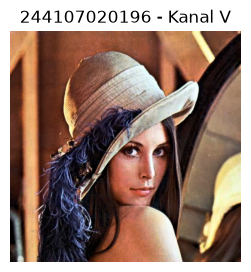

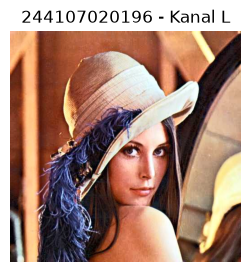

In [8]:
# Equalization warna pada lena.jpg
kanal_b, kanal_g, kanal_r = cv.split(lena)
kanal_b = cv.equalizeHist(kanal_b)
kanal_g = cv.equalizeHist(kanal_g)
kanal_r = cv.equalizeHist(kanal_r)
warna_equal = cv.merge([kanal_b, kanal_g, kanal_r])

ycrcb = cv.cvtColor(lena, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_equal = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(lena, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)
v_equal = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(lena, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
l_equal = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

for nomor, gambar, judul in [(1, lena, 'Asli'), (2, warna_equal, 'BGR'), (3, y_equal, 'Kanal Y'), (4, v_equal, 'Kanal V'), (5, l_equal, 'Kanal L')]:
    plt.figure(figsize=(4, 3))
    plt.imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')
    plt.show()

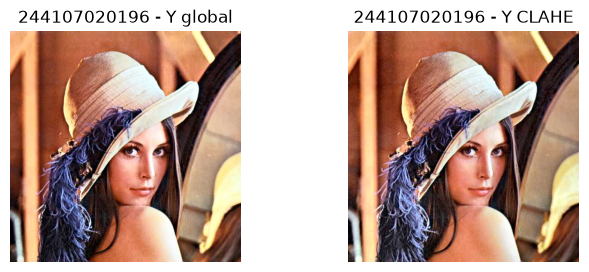

In [9]:
# CLAHE pada kanal Y
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
y_clahe = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(y_equal, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Y global')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(y_clahe, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Y CLAHE')
plt.axis('off')
plt.show()

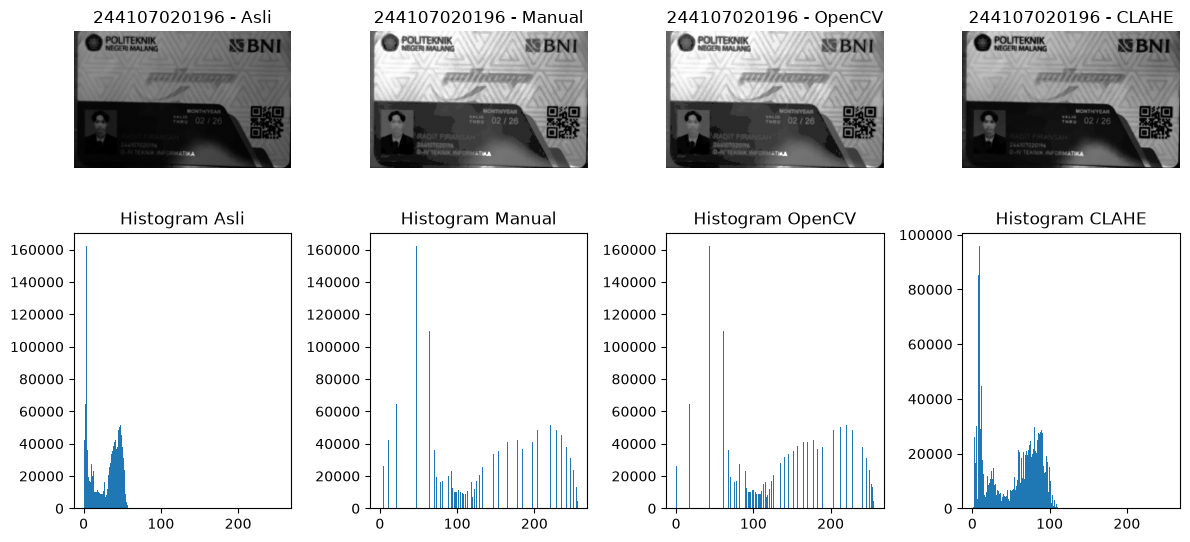

Selisih manual dan OpenCV: 4
PSNR asli dan hasil equalization: 6.675996036062822


In [10]:
# Equalization pada KTM1a.jpg
ktm1a = cv.imread(str(BASE / 'KTM1a.jpg'), cv.IMREAD_GRAYSCALE)

histogram = np.zeros(256, dtype=int)
for baris in ktm1a:
    for piksel in baris:
        histogram[piksel] += 1

cdf = np.cumsum(histogram) / ktm1a.size
pemetaan = np.round(255 * cdf).astype(np.uint8)
ktm1a_manual = pemetaan[ktm1a]
ktm1a_cv = cv.equalizeHist(ktm1a)

clahe_ktm = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
ktm1a_clahe = clahe_ktm.apply(ktm1a)

plt.figure(figsize=(12, 6))
for nomor, gambar, judul in [(1, ktm1a, 'Asli'), (2, ktm1a_manual, 'Manual'), (3, ktm1a_cv, 'OpenCV'), (4, ktm1a_clahe, 'CLAHE')]:
    plt.subplot(2, 4, nomor)
    plt.imshow(gambar, cmap='gray')
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')
    plt.subplot(2, 4, nomor + 4)
    plt.hist(gambar.ravel(), bins=256, range=(0, 256))
    plt.title('Histogram ' + judul)
plt.tight_layout()
plt.show()

mse = np.mean((ktm1a.astype(float) - ktm1a_manual.astype(float)) ** 2)
psnr = 10 * np.log10((255 ** 2) / mse)
print('Selisih manual dan OpenCV:', np.max(abs(ktm1a_manual.astype(int) - ktm1a_cv.astype(int))))
print('PSNR asli dan hasil equalization:', psnr)


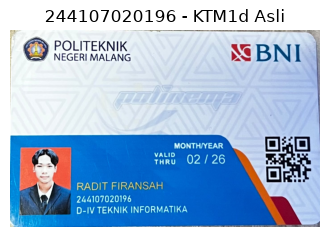

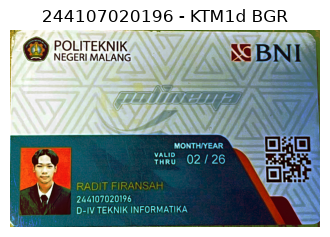

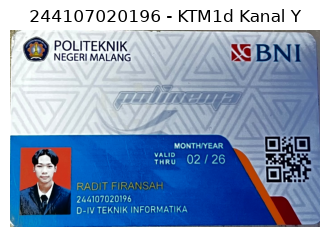

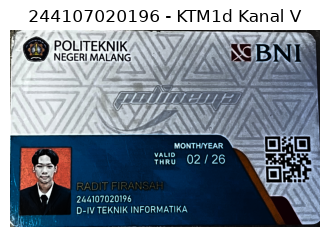

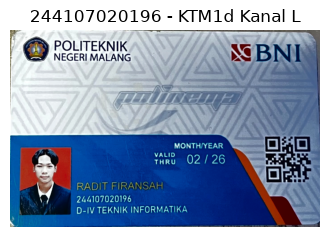

In [11]:
# Equalization warna pada KTM1d.jpg
ktm1d = cv.imread(str(BASE / 'KTM1d.jpg'))
ktm_b, ktm_g, ktm_r = cv.split(ktm1d)
ktm_bgr = cv.merge([cv.equalizeHist(ktm_b), cv.equalizeHist(ktm_g), cv.equalizeHist(ktm_r)])

ktm_ycrcb = cv.cvtColor(ktm1d, cv.COLOR_BGR2YCrCb)
ktm_y, ktm_cr, ktm_cb = cv.split(ktm_ycrcb)
ktm_y_equal = cv.cvtColor(cv.merge([cv.equalizeHist(ktm_y), ktm_cr, ktm_cb]), cv.COLOR_YCrCb2BGR)

ktm_hsv = cv.cvtColor(ktm1d, cv.COLOR_BGR2HSV)
ktm_h, ktm_s, ktm_v = cv.split(ktm_hsv)
ktm_v_equal = cv.cvtColor(cv.merge([ktm_h, ktm_s, cv.equalizeHist(ktm_v)]), cv.COLOR_HSV2BGR)

ktm_lab = cv.cvtColor(ktm1d, cv.COLOR_BGR2LAB)
ktm_l, ktm_a, ktm_b2 = cv.split(ktm_lab)
ktm_l_equal = cv.cvtColor(cv.merge([cv.equalizeHist(ktm_l), ktm_a, ktm_b2]), cv.COLOR_LAB2BGR)

for nomor, gambar, judul in [(1, ktm1d, 'Asli'), (2, ktm_bgr, 'BGR'), (3, ktm_y_equal, 'Kanal Y'), (4, ktm_v_equal, 'Kanal V'), (5, ktm_l_equal, 'Kanal L')]:
    plt.figure(figsize=(4, 3))
    plt.imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - KTM1d ' + judul)
    plt.axis('off')
    plt.show()


**Jawaban E-2:** Equalization manual dan `cv.equalizeHist` menghasilkan citra yang hampir sama. Perbedaan kecil dapat terjadi karena cara OpenCV menghitung CDF. PSNR dapat turun karena equalization memang mengubah intensitas piksel, bukan mempertahankan citra asli. Karena itu PSNR tidak cukup untuk menilai keterbacaan. CLAHE biasanya lebih membantu pada bagian gelap, tetapi clipLimit yang terlalu besar dapat memperkuat noise.


## E-3 Tugas Praktikum Dithering

### 1a. Proses dithering Floyd-Steinberg pada image lena.jpg

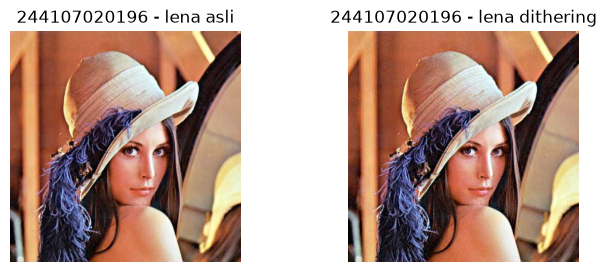

In [12]:
# Dithering Floyd-Steinberg pada lena.jpg
lena_float = lena.astype(np.float32)
lena_dither = np.zeros_like(lena, dtype=np.uint8)

for kanal in range(3):
    gambar = lena_float[:, :, kanal].copy()
    langkah = 255 / (PARAM['L'] - 1)
    for y in range(gambar.shape[0]):
        for x in range(gambar.shape[1]):
            nilai_lama = gambar[y, x]
            nilai_baru = round(nilai_lama / langkah) * langkah
            gambar[y, x] = nilai_baru
            error = nilai_lama - nilai_baru
            if x + 1 < gambar.shape[1]: gambar[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < gambar.shape[0]: gambar[y + 1, x - 1] += error * 3 / 16
            if y + 1 < gambar.shape[0]: gambar[y + 1, x] += error * 5 / 16
            if x + 1 < gambar.shape[1] and y + 1 < gambar.shape[0]: gambar[y + 1, x + 1] += error * 1 / 16
            gambar = np.clip(gambar, 0, 255)
    lena_dither[:, :, kanal] = gambar.astype(np.uint8)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(lena, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena dithering')
plt.axis('off')
plt.show()


### 1b. Proses dithering Floyd-Steinberg pada image KTM1b.jpg

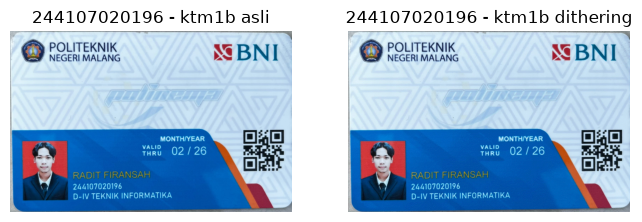

In [14]:
# Dithering Floyd-Steinberg pada KTM1b.jpg
ktm1b = cv.imread(str(BASE / 'KTM1b.jpg'))
ktm1b_float = ktm1b.astype(np.float32)
ktm1b_dither = np.zeros_like(ktm1b, dtype=np.uint8)

for kanal in range(3):
    gambar = ktm1b_float[:, :, kanal].copy()
    langkah = 255 / (PARAM['L'] - 1)
    for y in range(gambar.shape[0]):
        for x in range(gambar.shape[1]):
            nilai_lama = gambar[y, x]
            nilai_baru = round(nilai_lama / langkah) * langkah
            gambar[y, x] = nilai_baru
            error = nilai_lama - nilai_baru
            if x + 1 < gambar.shape[1]: gambar[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < gambar.shape[0]: gambar[y + 1, x - 1] += error * 3 / 16
            if y + 1 < gambar.shape[0]: gambar[y + 1, x] += error * 5 / 16
            if x + 1 < gambar.shape[1] and y + 1 < gambar.shape[0]: gambar[y + 1, x + 1] += error * 1 / 16
        
    gambar = np.clip(gambar, 0, 255)
    ktm1b_dither[:, :, kanal] = gambar.astype(np.uint8)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(ktm1b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ktm1b asli')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ktm1b dithering')
plt.axis('off')
plt.show()


### 2. Menerapkan dithering Floyd-Steinberg pada hasil ekualisasi pada image KTM1a.jpg

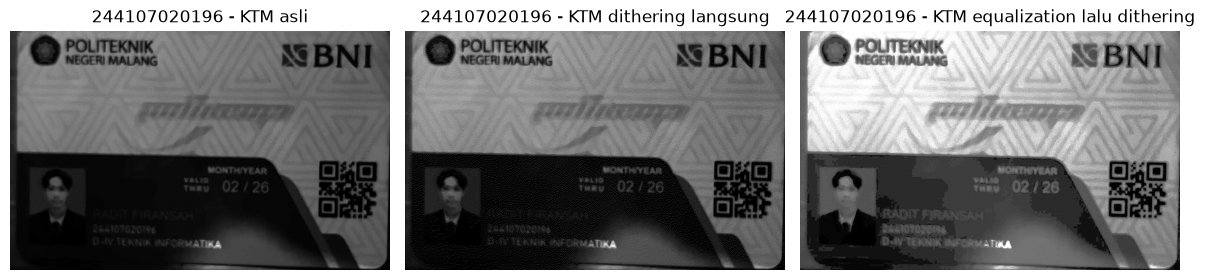

In [15]:
def floyd_steinberg_dithering(gambar, L):
    hasil = gambar.astype(np.float32).copy()
    tinggi, lebar = hasil.shape
    langkah = 255 / (L - 1)
    for y in range(tinggi):
        for x in range(lebar):

            nilai_lama = hasil[y, x]
            nilai_baru = round(nilai_lama / langkah) * langkah
            hasil[y, x] = nilai_baru
            error = nilai_lama - nilai_baru

            if x + 1 < lebar:
                hasil[y, x + 1] += error * 7 / 16

            if y + 1 < tinggi:
                if x > 0:
                    hasil[y + 1, x - 1] += error * 3 / 16

                hasil[y + 1, x] += error * 5 / 16

                if x + 1 < lebar:
                    hasil[y + 1, x + 1] += error * 1 / 16

    hasil = np.clip(hasil, 0, 255)
    return hasil.astype(np.uint8)

ktm_langsung = floyd_steinberg_dithering(
    ktm1a,
    PARAM['L']
)

ktm_setelah_equalisasi = floyd_steinberg_dithering(
    ktm1a_cv,
    PARAM['L']
)

plt.figure(figsize=(12, 3))

for nomor, gambar, judul in [
    (1, ktm1a, 'KTM asli'),
    (2, ktm_langsung, 'KTM dithering langsung'),
    (3, ktm_setelah_equalisasi, 'KTM equalization lalu dithering')
]:
    plt.subplot(1, 3, nomor)
    plt.imshow(gambar, cmap='gray')
    plt.title(NIM + ' - ' + judul)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Jawaban E-3:** Floyd-Steinberg membagikan error ke piksel kanan dan piksel di baris berikutnya menggunakan bobot 7/16, 3/16, 5/16, dan 1/16. Equalization sebelum dithering memperlebar sebaran intensitas sehingga detail area gelap lebih terlihat.